# 05 · Streaming in LangGraph

> Workshop module · builds on notebooks 01 (agents) & 04 (persistence).

Agents can take many seconds - calling models, running tools, looping. **Streaming** lets you show
progress *as it happens* instead of waiting for the final answer: live tokens, tool activity, and
state updates.

LangGraph streams through **`.stream()`** (sync) / **`.astream()`** (async) with a **`stream_mode`**,
plus **`.astream_events()`** for fine-grained events.

> ⚠️ **Version note for the workshop:** the current docs page shows a brand-new API,
> `graph.stream_events(..., version="v3")`. That is **not yet in the installed release** - calling it
> raises `NotImplementedError`. This notebook uses the **stable, shipping** API (`stream_mode=...` and
> `astream_events(version="v2")`). We show the v3 syntax at the end as a *preview* of what's coming.

## 0 · Setup - a small agent to stream

In [1]:
import os
# --- Load API keys from the project .env, no matter how/where Jupyter was started ---
_ENV_PATH = "/Users/datasense/Desktop/langgrapgh-agent/.env"
for _line in open(_ENV_PATH):
    _line = _line.strip()
    if _line and not _line.startswith("#") and "=" in _line:
        _k, _v = _line.split("=", 1)
        os.environ[_k.strip()] = _v.strip().strip('"').strip("'")
print("Loaded keys:", [k for k in ("OPENAI_API_KEY", "TAVILY_API_KEY", "SERPAPI_API_KEY") if os.getenv(k)])
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY missing from .env"

from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage

@tool
def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

agent = create_agent("openai:gpt-4o-mini", tools=[add, multiply],
                     system_prompt="You are a concise arithmetic assistant.")
print("agent ready")

Loaded keys: ['OPENAI_API_KEY', 'TAVILY_API_KEY', 'SERPAPI_API_KEY']


agent ready


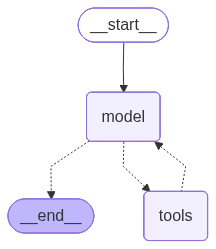

In [2]:
from IPython.display import Image, display

# the agent we'll stream from - the same model <-> tools loop as notebook 01
display(Image(agent.get_graph().draw_mermaid_png()))

## 1 · Stream modes - the menu

`.stream(input, stream_mode=...)` controls *what* you get on each iteration:

| mode | yields | use it for |
|---|---|---|
| `"values"` | the **full state** after each step | redraw the whole conversation |
| `"updates"` | only the **node's delta** (`{node: update}`) | progress log of which node ran |
| `"messages"` | **token-by-token** `(chunk, metadata)` | live "typing" output |
| `"custom"` | whatever a node `writer(...)`s | your own progress signals |
| `"debug"` | verbose execution trace | deep debugging |

You can also pass a **list** of modes. Let's see each.

## 2 · `updates` - a progress log of nodes

Great for a status line: *which node just ran and what did it produce.*

In [3]:
for chunk in agent.stream({"messages": [HumanMessage("What is 21 + 21, then times 2?")]},
                          stream_mode="updates"):
    for node, update in chunk.items():
        msg = update["messages"][-1]
        if getattr(msg, "tool_calls", None):
            print(f"[{node}] -> wants tools: {[tc['name'] for tc in msg.tool_calls]}")
        elif msg.type == "tool":
            print(f"[{node}] -> tool result: {msg.content}")
        else:
            print(f"[{node}] -> {msg.content}")

[model] -> wants tools: ['add', 'multiply']
[tools] -> tool result: 42
[tools] -> tool result: 42


[model] -> 21 + 21 is 42, and when you multiply 21 by 2, the result is also 42.


## 3 · `values` - the full state each step

Each iteration is the *entire* state. Notice the message list growing.

In [4]:
for snapshot in agent.stream({"messages": [HumanMessage("What is 6 times 7?")]},
                             stream_mode="values"):
    print(f"{len(snapshot['messages'])} msgs | last = {snapshot['messages'][-1].type}")

1 msgs | last = human


2 msgs | last = ai
3 msgs | last = tool


4 msgs | last = ai


## 4 · `messages` - live token streaming ✨

This is the one users *feel*. `stream_mode="messages"` yields `(message_chunk, metadata)` pairs as the
model generates. Concatenate `.content` for a ChatGPT-style typing effect.

In [5]:
print("Assistant: ", end="", flush=True)
for token, meta in agent.stream({"messages": [HumanMessage("In one sentence, what is LangGraph?")]},
                                stream_mode="messages"):
    if token.content and meta["langgraph_node"] == "model":
        print(token.content, end="", flush=True)
print()

Assistant: 

Lang

Graph

 is

 a

...

 data

 sources

 and

 workflows

.

## 5 · Multiple modes at once

Pass a list → each iteration is a `(mode, payload)` tuple, so you can drive a progress log **and** a
token stream from a single loop.

In [6]:
for mode, payload in agent.stream({"messages": [HumanMessage("What is 100 + 1?")]},
                                  stream_mode=["updates", "messages"]):
    if mode == "updates":
        node = list(payload)[0]
        print(f"\n[node: {node}]")
    elif mode == "messages":
        token, meta = payload
        if token.content:
            print(token.content, end="", flush=True)
print()


[node: model]
101


[node: tools]


100

 +

1

 equals

101

.


[node: model]



## 6 · `custom` - emit your own progress

Inside a node, call `get_stream_writer()` and push anything (dicts, strings). It surfaces under
`stream_mode="custom"`. Perfect for "Searching the web…", "Reading 3 docs…" style UI signals that the
model/tools can't express on their own.

In [7]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.config import get_stream_writer
import time

def worker(state: MessagesState):
    writer = get_stream_writer()
    writer({"status": "starting"})
    for i in range(1, 4):
        time.sleep(0.1)
        writer({"progress": f"step {i}/3"})
    writer({"status": "done"})
    return {"messages": [{"role": "assistant", "content": "finished the job"}]}

g = StateGraph(MessagesState)
g.add_node("worker", worker)
g.add_edge(START, "worker")
g.add_edge("worker", END)
custom_graph = g.compile()

for update in custom_graph.stream({"messages": [HumanMessage("go")]}, stream_mode="custom"):
    print("custom event:", update)

custom event: {'status': 'starting'}


custom event: {'progress': 'step 1/3'}


custom event: {'progress': 'step 2/3'}


custom event: {'progress': 'step 3/3'}
custom event: {'status': 'done'}


## 7 · Fine-grained events - `astream_events`

`stream_mode` works at the **node** level. For **everything** (model start/stream/end, each tool
start/end, chains), use **`astream_events(version="v2")`**. Every event has a `event` type, a `name`,
and `data`. Filter for what you care about.

Common event types: `on_chat_model_stream` (a token), `on_tool_start`, `on_tool_end`.

In [8]:
inp = {"messages": [HumanMessage("What is 12 times 12? Use the tool, then state the answer.")]}

async for ev in agent.astream_events(inp, version="v2"):
    kind = ev["event"]
    if kind == "on_chat_model_stream":
        chunk = ev["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="", flush=True)
    elif kind == "on_tool_start":
        print(f"\n  🔧 tool start: {ev['name']}({ev['data'].get('input')})")
    elif kind == "on_tool_end":
        print(f"  tool end:   {ev['name']} -> {ev['data'].get('output')}")
print()


  🔧 tool start: multiply({'a': 12, 'b': 12})
  tool end:   multiply -> content='144' name='multiply' tool_call_id='call_AvCf6rKcaLx6rfPmmhfPKoVP'


12

 times

12

 is

144

.

## 8 · Preview - the upcoming v3 `stream_events` API

The latest docs describe a cleaner, projection-based API. It is **not in the installed release yet**
(it raises `NotImplementedError` here), so this cell is **reference only** - don't run it today. It's
worth showing students where the API is heading:

```python
# FUTURE API (docs preview) - not runnable in this release
stream = graph.stream_events(
    {"messages": [{"role": "user", "content": "What is 42 * 17?"}]},
    version="v3",
)

# token streaming becomes a clean projection:
for message in stream.messages:
    for token in message.text:
        print(token, end="", flush=True)

final_state = stream.output            # the final state
# other projections: stream.values, stream.subgraphs, stream.tool_calls
```

Key idea: instead of filtering raw events, you read named **projections**
(`stream.messages`, `stream.values`, `stream.subgraphs`, `stream.tool_calls`) and multiple consumers
can read them concurrently.

## Recap

| you want… | use |
|---|---|
| which node ran | `stream_mode="updates"` |
| full state snapshots | `stream_mode="values"` |
| live typing / tokens | `stream_mode="messages"` |
| your own progress signals | `get_stream_writer()` + `stream_mode="custom"` |
| every model/tool event | `astream_events(version="v2")` |
| (coming soon) projections | `stream_events(version="v3")` |

Because `create_agent` is just a LangGraph, **all** of these work on it unchanged - same as the raw
graphs we built in notebook 01.

### 🏋️ Exercises
1. Build a CLI-style loop that prints tokens live with `stream_mode="messages"`.
2. Add a `web_search` tool and watch `on_tool_start` / `on_tool_end` fire in `astream_events`.
3. Emit a custom `{"phase": ...}` event from a tool and render it as a status line.